In [7]:
import numpy as np
import torch
from matplotlib import pyplot as plt
from smalldiffusion.model_unet import myUnet
from smalldiffusion.model import Scaled

%load_ext autoreload
%autoreload 2

# Pick a region
wave = np.load('../datasets/wave_mean.npy')
forcing = np.load('../datasets/forcing.npy')    
np.save('../datasets/train/wave.npy', wave[:401,:,50:114,0:64])
np.save('../datasets/train/forcing.npy', forcing[:401,:,50:114,0:64])
np.save('../datasets/test/wave.npy', wave[402:,:,50:114,0:64])
np.save('../datasets/test/forcing.npy', forcing[402:,:,50:114,0:64])

# mask = np.load('../datasets/mask.npy')
# np.save('../datasets/train/mask.npy', mask[50:114,0:64])
# np.save('../datasets/test/mask.npy', mask[50:114,0:64])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from smalldiffusion.data import npyData
from torch.utils.data import DataLoader
from smalldiffusion.diffusion import ScheduleLogLinear
from accelerate import Accelerator
a = Accelerator()

train = npyData('train/wave.npy', 'train/forcing.npy', 'train/mask.npy', compute_stats=True)
test = npyData('test/wave.npy', 'test/forcing.npy', 'test/mask.npy', compute_stats=False,
               meanx=train.meanx, stdx=train.stdx, meanf=train.meanf, stdf=train.stdf)

loader = DataLoader(train, batch_size=8, shuffle=True)
schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=20, N=80)

Computing dataset mean and std...


/Users/jwu/Work/Code/diffusion/smalldiffusion/src/smalldiffusion/data.py:94: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:212.)
  x = torch.from_numpy(self.X[idx]).float()


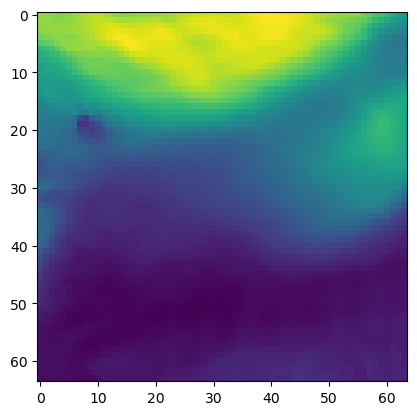

In [4]:
from matplotlib import pyplot as plt
loader_iter = iter(loader)   
x, f = next(loader_iter)
plt.imshow(x[0,0].numpy()); plt.show()

In [5]:
from smalldiffusion.diffusion import generate_train_sample
x, f = next(loader_iter)
x0 = [x, f]
x0, sigma, eps, cond = generate_train_sample(x0, schedule, conditional=True)

In [7]:
sigma

tensor([[[[1.6284e-01]]],


        [[[5.1327e-02]]],


        [[[1.6499e+01]]],


        [[[6.9405e+00]]],


        [[[1.7929e-01]]],


        [[[1.3346e-02]]],


        [[[1.1155e+00]]],


        [[[5.2004e+00]]]])

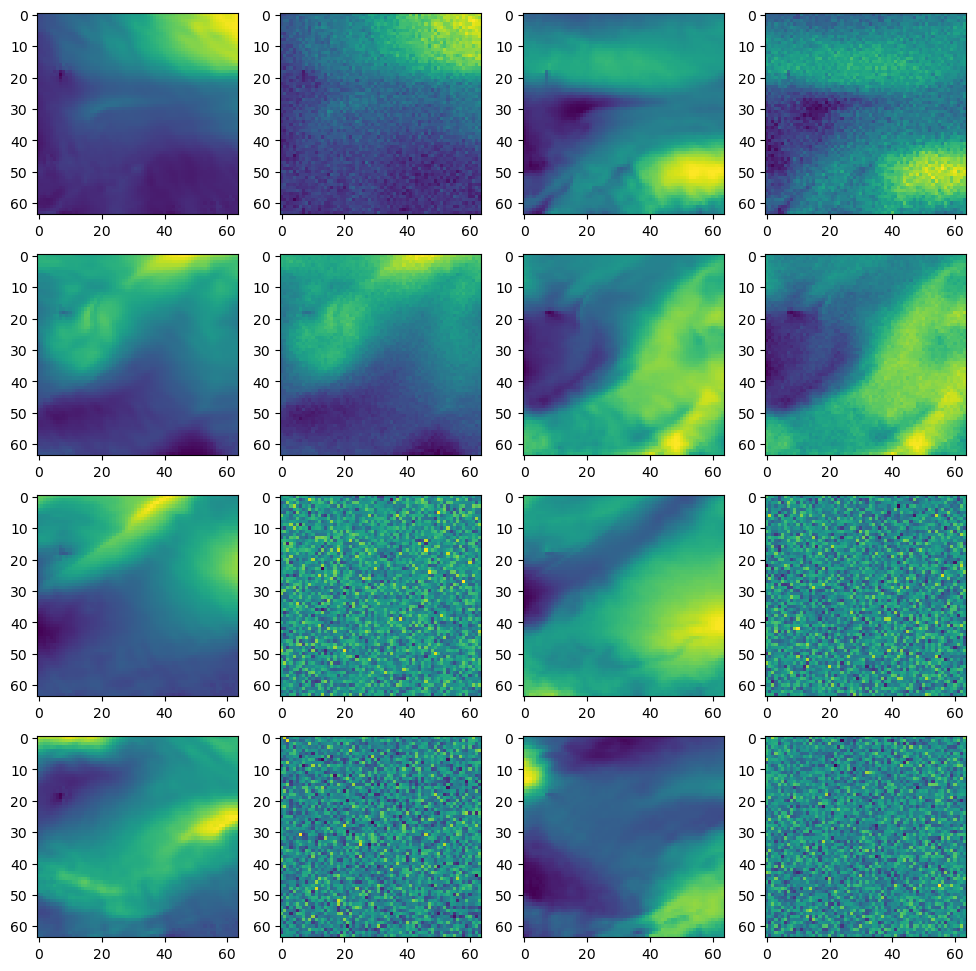

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(12,12))
for i in range(4):
    axes[i,0].imshow(x0[i,0])
    axes[i,1].imshow(x0[i,0] + eps[i,0]*sigma[i][0])
    axes[i,2].imshow(x0[i,1])
    axes[i,3].imshow(x0[i,1] + eps[i,1]*sigma[i][0])


In [ ]:
model = Scaled(myUnet)(in_dim=64, in_ch=4, out_ch=4, ch=64, precond_ch=3, 
                       ch_mult=(1, 2, 2), attn_resolutions=(16,))
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
model, optimizer, loader = a.prepare(model, optimizer, loader)

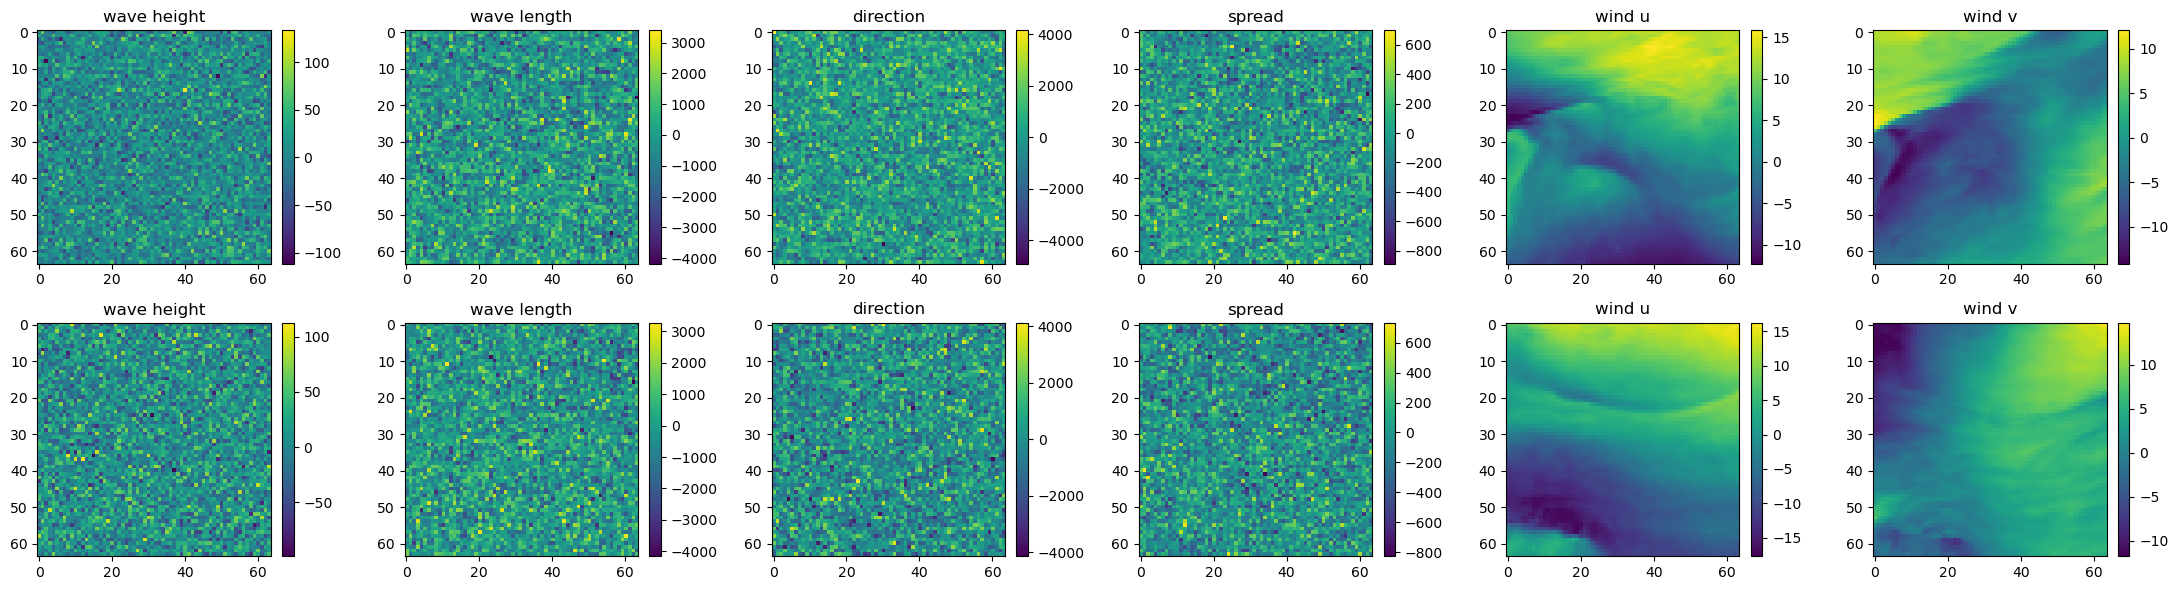

In [ ]:
def plot_sample(x, f):
    n = x.shape[0]
    fig, axes = plt.subplots(n, 6, figsize=[22, 3*n], dpi=100)
    titles = ['wave height','wave length','direction','spread','wind u','wind v']
    for i in range(n):
        imgs = [
            axes[i, 0].imshow(x[i,0]),
            axes[i, 1].imshow(x[i,1]),
            axes[i, 2].imshow(x[i,2]),
            axes[i, 3].imshow(x[i,3]),
            axes[i, 4].imshow(f[i,0]),
            axes[i, 5].imshow(f[i,1]),
        ]
        for j in range(6):
            axes[i,j].set_title(titles[j])
            fig.colorbar(imgs[j], ax=axes[i,j], fraction=0.046, pad=0.04)
    plt.tight_layout()
    return fig

from smalldiffusion.diffusion import samples
x, f = next(loader_iter)
*xt, x0 = samples(model, schedule.sample_sigmas(20), gam=1.6, batchsize=2, accelerator=a, cond=f[:2])


In [43]:
print("Device:", a.device)
print("Is distributed:", a.distributed_type)
print("Num processes:", a.num_processes)
print("Mixed precision:", a.mixed_precision)
# print("Compute dtype:", a.compute_dtype)
# print("Param dtype:", a.dtype)

Device: mps
Is distributed: DistributedType.NO
Num processes: 1
Mixed precision: no
